In [3]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [7]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [8]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

In [9]:
trades['timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: timestamp, dtype: float64

In [10]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')

In [11]:
trades['date'] = trades['timestamp'].dt.normalize()

In [12]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

In [13]:
df = trades.merge(sentiment, on='date', how='left')

In [14]:
df['classification'].value_counts(dropna=False)

classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [15]:
df = df.dropna(subset=['classification'])

In [16]:
def map_sentiment(x):
    if 'fear' in x.lower():
        return 'fear'
    elif 'greed' in x.lower():
        return 'greed'
    else:
        return None

df['sentiment_group'] = df['classification'].apply(map_sentiment)
df = df.dropna(subset=['sentiment_group'])

In [17]:
df['sentiment_group'].value_counts()

sentiment_group
fear     133871
greed     43251
Name: count, dtype: int64

In [18]:
df.groupby('sentiment_group')['closed_pnl'].mean()

sentiment_group
fear     50.047622
greed    77.838247
Name: closed_pnl, dtype: float64

In [19]:
df['win'] = df['closed_pnl'] > 0
df.groupby('sentiment_group')['win'].mean()

sentiment_group
fear     0.415146
greed    0.453492
Name: win, dtype: float64

In [21]:
df['size_group'] = pd.qcut(df['size_usd'], q=2, labels=['low_size','high_size'])

In [22]:
df.groupby(['sentiment_group','size_group']).size()

sentiment_group  size_group
fear             low_size      66270
                 high_size     67601
greed            low_size      22291
                 high_size     20960
dtype: int64

In [23]:
pd.crosstab(df['sentiment_group'], df['size_group'], normalize='index')

size_group,low_size,high_size
sentiment_group,,
fear,0.495029,0.504971
greed,0.515387,0.484613


In [24]:
df.groupby(['sentiment_group','size_group'])['closed_pnl'].mean()

sentiment_group  size_group
fear             low_size        3.259548
                 high_size      95.914483
greed            low_size       11.530981
                 high_size     148.356152
Name: closed_pnl, dtype: float64

In [25]:
df['win'] = df['closed_pnl'] > 0

df.groupby(['sentiment_group','size_group'])['win'].mean()

sentiment_group  size_group
fear             low_size      0.404044
                 high_size     0.426029
greed            low_size      0.499080
                 high_size     0.405010
Name: win, dtype: float64

In [ ]:
#Are there more trades in Greed or Fear?
df.groupby('sentiment_group').size()


sentiment_group
fear     133871
greed     43251
dtype: int64

In [ ]:
#More long trades in Greed?
#More shorts in Fear?

pd.crosstab(df['sentiment_group'], df['side'], normalize='index')

side,BUY,SELL
sentiment_group,,
fear,0.493617,0.506383
greed,0.434487,0.565513


In [28]:
#Segment Analysis
#This gives us:

#behavior + performance together

df.groupby(['sentiment_group','size_group'])['closed_pnl'].mean()
df.groupby(['sentiment_group','size_group'])['win'].mean()

sentiment_group  size_group
fear             low_size      0.404044
                 high_size     0.426029
greed            low_size      0.499080
                 high_size     0.405010
Name: win, dtype: float64

In [29]:
#converting results into tables for better visualization

# Win rate table
win_table = df.groupby(['sentiment_group','size_group'])['win'].mean().reset_index()

# PnL table
pnl_table = df.groupby(['sentiment_group','size_group'])['closed_pnl'].mean().reset_index()

# Trade count
trade_count = df.groupby('sentiment_group').size().reset_index(name='num_trades')

# Long/Short ratio
ls_ratio = pd.crosstab(df['sentiment_group'], df['side'], normalize='index').reset_index()

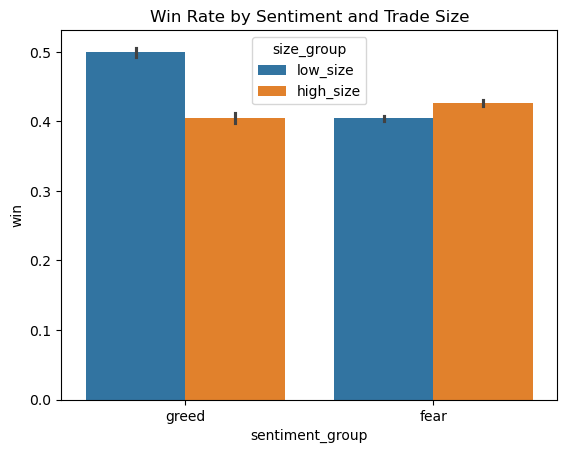

In [30]:
#Chart 1: Win Rate vs Sentiment + Size
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='sentiment_group', y='win', hue='size_group', data=df)
plt.title("Win Rate by Sentiment and Trade Size")
plt.show()

## Insight: Win Rate by Sentiment and Trade Size

- During **Greed**, low-size trades have a significantly higher win rate (~50%) compared to high-size trades (~40%).
- During **Fear**, high-size trades slightly outperform low-size trades, but overall win rates are lower than Greed.

### Interpretation:
- Traders taking , indicating overconfidence and excessive risk-taking.
- Smaller trades are more effective during Greed, suggesting disciplined strategies outperform aggressive ones.

### Key Takeaway:
Avoid large position sizes during Greed phases; prefer controlled, smaller trades.

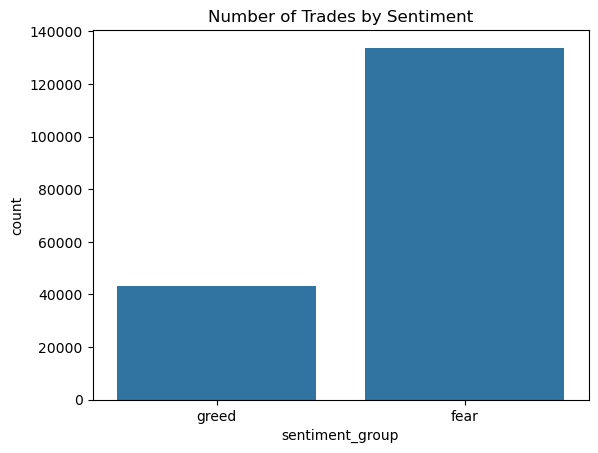

In [ ]:
#trade distribution by sentiment
sns.countplot(x='sentiment_group', data=df)
plt.title("Number of Trades by Sentiment")
plt.show()

## Insight: Trade Activity by Sentiment

- The number of trades during **Fear (~133k)** is significantly higher than during **Greed (~43k)**.

### Interpretation:
- Traders are more active during Fear periods, likely due to panic, volatility, or rapid market movements.
- Increased activity may indicate overtrading or reactive behavior rather than strategic decision-making.

### Key Takeaway:
Fear-driven markets lead to higher trading frequency, but this does not necessarily imply better performance.

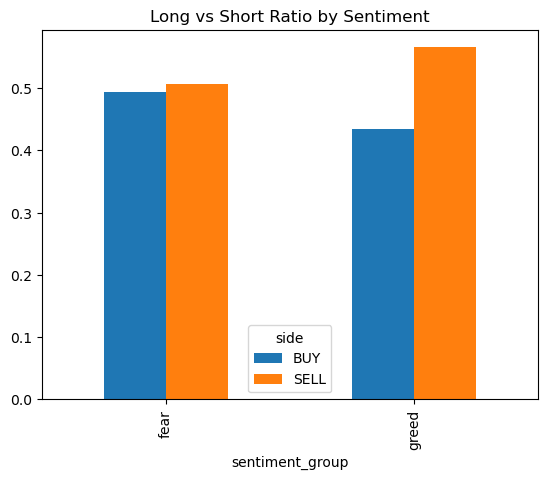

In [ ]:
#long vs short ratio by sentiment
pd.crosstab(df['sentiment_group'], df['side'], normalize='index').plot(kind='bar')
plt.title("Long vs Short Ratio by Sentiment")
plt.show()

## Insight: Long vs Short Behavior by Sentiment

- In both **Fear and Greed**, SELL trades dominate over BUY trades.
- The dominance of SELL trades is even stronger during Greed (~56%) compared to Fear (~50%).

### Interpretation:
- Traders are more inclined to sell even during Greed, possibly indicating profit-taking or contrarian strategies.
- This suggests that traders may not fully trust bullish sentiment and prefer to secure gains.

### Key Takeaway:
Sell-side bias persists across market conditions, highlighting cautious or profit-booking behavior among traders.

### Insights:
From our win rate:

Fear → high_size = 0.426
Greed → high_size = 0.405
High-size trades perform worse during Greed compared to Fear, indicating that aggressive positioning in bullish sentiment leads to reduced success rates.

### From trade count:

fear  = 133871  
greed = 43251
Significantly more trades occur during Fear periods, suggesting heightened market activity and possibly panic-driven trading behavior.

### From long/short:

More SELL in both cases
Even higher SELL in Greed
Traders exhibit a higher proportion of sell orders even during Greed phases, indicating possible profit-taking or contrarian strategies.

### Strategy Recommendations
-Reduce position size during Greed phases
-Avoid overtrading during Fear
-Prefer controlled risk exposure
-Consider short/profit-taking strategies

In [ ]:
#Strategy Recommendations
#Reduce position size during Greed phases
#Avoid overtrading during Fear
#Prefer controlled risk exposure
#Consider short/profit-taking strategies